In [1]:
%pip install pandas numpy seaborn matplotlib scikit-learn xgboost lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\HP\Downloads\Data Science UNI project\gold_dataset.csv")
df_before = df.copy()

In [3]:
df.head()

,Date,Gold_Price,Silver,Oil_WTI,Platinum,Copper,SP500,Nasdaq,Dow_Jones,MSCI_World,...,Momentum_14d,Gold_Silver_Ratio,Gold_Oil_Ratio,DayOfWeek,Month,Quarter,Year,Target_NextDay,Target_Next7d,Target_Direction
0,2000-08-30,273.899994,4.930,33.400002,591.400024,0.8850,1502.589966,4103.810059,11103.009766,NaN,...,NaN,55.557810,8.200598,2,8,3,2000,278.299988,273.299988,1
1,2000-08-31,278.299988,5.003,33.099998,586.700012,0.8850,1517.680054,4206.350098,11215.099609,NaN,...,NaN,55.626624,8.407855,3,8,3,2000,277.000000,273.100006,0
2,2000-09-01,277.000000,5.004,33.380001,595.299988,0.8890,1520.770020,4234.330078,11238.780273,NaN,...,NaN,55.355713,8.298382,4,9,3,2000,NaN,272.899994,0
3,2000-09-05,275.799988,4.998,33.799999,601.299988,0.9060,1507.079956,4143.180176,11260.610352,NaN,...,NaN,55.182069,8.159763,1,9,3,2000,274.200012,272.399994,0
4,2000-09-06,274.200012,4.983,34.950001,611.099976,0.9015,1492.250000,4013.340088,11310.639648,NaN,...,NaN,55.027097,7.845494,2,9,3,2000,274.000000,272.299988,0


In [4]:
df.shape

(6419, 70)

In [5]:
df.columns

Index(['Date', 'Gold_Price', 'Silver', 'Oil_WTI', 'Platinum', 'Copper',
       'SP500', 'Nasdaq', 'Dow_Jones', 'MSCI_World', 'DXY', 'EUR_USD',
       'JPY_USD', 'GBP_USD', 'CNY_USD', 'US_10Y_Yield', 'US_2Y_Yield',
       'TIP_ETF', 'VIX', 'Gold_ETF_GLD', 'CPI', 'Fed_Rate', 'Real_Rate_10Y',
       'PPI', 'M2_Money', 'Treasury_Spread', 'Unemployment', 'GDP_Growth',
       'Industrial_Prod', 'Consumer_Conf', 'MA7', 'EMA7', 'MA14', 'EMA14',
       'MA21', 'EMA21', 'MA50', 'EMA50', 'MA200', 'EMA200', 'Return_1d',
       'Return_3d', 'Return_7d', 'Return_14d', 'Return_30d', 'Lag_1d',
       'Lag_3d', 'Lag_7d', 'Lag_14d', 'Lag_21d', 'RSI_14', 'MACD',
       'MACD_Signal', 'MACD_Hist', 'BB_Upper', 'BB_Lower', 'BB_Width',
       'BB_Pos', 'Volatility_7d', 'Volatility_30d', 'Momentum_14d',
       'Gold_Silver_Ratio', 'Gold_Oil_Ratio', 'DayOfWeek', 'Month', 'Quarter',
       'Year', 'Target_NextDay', 'Target_Next7d', 'Target_Direction'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6419 entries, 0 to 6418
Data columns (total 70 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               6419 non-null   object 
 1   Gold_Price         6419 non-null   float64
 2   Silver             6418 non-null   float64
 3   Oil_WTI            6418 non-null   float64
 4   Platinum           5732 non-null   float64
 5   Copper             6418 non-null   float64
 6   SP500              6414 non-null   float64
 7   Nasdaq             6414 non-null   float64
 8   Dow_Jones          6414 non-null   float64
 9   MSCI_World         3571 non-null   float64
 10  DXY                6416 non-null   float64
 11  EUR_USD            5579 non-null   float64
 12  JPY_USD            6389 non-null   float64
 13  GBP_USD            5592 non-null   float64
 14  CNY_USD            5975 non-null   float64
 15  US_10Y_Yield       6409 non-null   float64
 16  US_2Y_Yield        6409 

In [7]:
for col in df.columns:
    print(col, " = ",df[col].isnull().sum())

Date  =  0
Gold_Price  =  0
Silver  =  1
Oil_WTI  =  1
Platinum  =  687
Copper  =  1
SP500  =  5
Nasdaq  =  5
Dow_Jones  =  5
MSCI_World  =  2848
DXY  =  3
EUR_USD  =  840
JPY_USD  =  30
GBP_USD  =  827
CNY_USD  =  444
US_10Y_Yield  =  10
US_2Y_Yield  =  10
TIP_ETF  =  818
VIX  =  5
Gold_ETF_GLD  =  1056
CPI  =  0
Fed_Rate  =  0
Real_Rate_10Y  =  0
PPI  =  0
M2_Money  =  0
Treasury_Spread  =  0
Unemployment  =  0
GDP_Growth  =  84
Industrial_Prod  =  0
Consumer_Conf  =  0
MA7  =  1372
EMA7  =  0
MA14  =  2773
EMA14  =  0
MA21  =  3969
EMA21  =  0
MA50  =  6130
EMA50  =  0
MA200  =  6419
EMA200  =  0
Return_1d  =  1
Return_3d  =  3
Return_7d  =  6
Return_14d  =  13
Return_30d  =  29
Lag_1d  =  239
Lag_3d  =  253
Lag_7d  =  257
Lag_14d  =  260
Lag_21d  =  261
RSI_14  =  2955
MACD  =  0
MACD_Signal  =  0
MACD_Hist  =  0
BB_Upper  =  3821
BB_Lower  =  3821
BB_Width  =  3821
BB_Pos  =  3821
Volatility_7d  =  6
Volatility_30d  =  29
Momentum_14d  =  260
Gold_Silver_Ratio  =  1
Gold_Oil_Ratio

In [8]:
df.isnull().sum()

Date                  0
Gold_Price            0
Silver                1
Oil_WTI               1
Platinum            687
                   ... 
Quarter               0
Year                  0
Target_NextDay      238
Target_Next7d       251
Target_Direction      0
Length: 70, dtype: int64

In [9]:
df.describe()

,Gold_Price,Silver,Oil_WTI,Platinum,Copper,SP500,Nasdaq,Dow_Jones,MSCI_World,DXY,...,Momentum_14d,Gold_Silver_Ratio,Gold_Oil_Ratio,DayOfWeek,Month,Quarter,Year,Target_NextDay,Target_Next7d,Target_Direction
count,6419.000000,6418.000000,6418.000000,5732.000000,6418.000000,6414.000000,6414.000000,6414.000000,3571.000000,6416.000000,...,6159.000000,6418.000000,6418.000000,6419.000000,6419.000000,6419.000000,6419.000000,6181.000000,6168.000000,6419.000000
mean,1285.970462,18.584920,64.770570,1093.479588,2.871972,2336.385885,6252.892145,19485.196210,89.983967,92.528533,...,9.342799,69.170258,20.522467,2.020876,6.546814,2.514566,2012.973672,1288.646027,1293.606063,0.505686
std,806.472608,11.566541,24.525810,367.649752,1.201432,1525.610178,5555.604981,10867.973573,38.426349,11.131566,...,67.713223,13.268056,13.406191,1.398548,3.447118,1.121157,7.385234,809.681440,814.117404,0.500007
min,255.100006,4.026000,-37.630001,412.500000,0.604000,676.530029,1114.109985,6547.049805,37.733318,71.330002,...,-770.600098,31.995078,-45.219238,0.000000,1.000000,1.000000,2000.000000,255.100006,255.100006,0.000000
25%,652.800018,12.252250,46.517499,870.500000,2.147000,1207.029999,2207.840027,10679.027100,58.769709,82.550003,...,-16.199951,59.423771,11.490888,1.000000,4.000000,2.000000,2007.000000,653.400024,656.700012,0.000000
50%,1252.099976,17.038500,63.809999,979.500000,3.052250,1643.095032,3600.234985,15077.024902,78.583092,93.080002,...,5.100006,68.632369,17.021091,2.000000,7.000000,3.000000,2013.000000,1252.699951,1253.800049,1.000000
75%,1700.350037,23.754000,81.995001,1376.799988,3.709500,2972.850037,8195.647461,26475.987305,116.109600,99.522497,...,31.400024,78.757052,25.267730,3.000000,10.000000,4.000000,2019.000000,1702.400024,1704.575012,1.000000
max,5318.399902,115.080002,145.289993,2852.399902,6.175500,6978.600098,23958.470703,50188.140625,192.369995,120.900002,...,851.899902,125.888376,167.652339,4.000000,12.000000,4.000000,2026.000000,5318.399902,5318.399902,1.000000


In [10]:
for col in df.columns:
    print(col, " = ",df[col].isnull().sum())

Date  =  0
Gold_Price  =  0
Silver  =  1
Oil_WTI  =  1
Platinum  =  687
Copper  =  1
SP500  =  5
Nasdaq  =  5
Dow_Jones  =  5
MSCI_World  =  2848
DXY  =  3
EUR_USD  =  840
JPY_USD  =  30
GBP_USD  =  827
CNY_USD  =  444
US_10Y_Yield  =  10
US_2Y_Yield  =  10
TIP_ETF  =  818
VIX  =  5
Gold_ETF_GLD  =  1056
CPI  =  0
Fed_Rate  =  0
Real_Rate_10Y  =  0
PPI  =  0
M2_Money  =  0
Treasury_Spread  =  0
Unemployment  =  0
GDP_Growth  =  84
Industrial_Prod  =  0
Consumer_Conf  =  0
MA7  =  1372
EMA7  =  0
MA14  =  2773
EMA14  =  0
MA21  =  3969
EMA21  =  0
MA50  =  6130
EMA50  =  0
MA200  =  6419
EMA200  =  0
Return_1d  =  1
Return_3d  =  3
Return_7d  =  6
Return_14d  =  13
Return_30d  =  29
Lag_1d  =  239
Lag_3d  =  253
Lag_7d  =  257
Lag_14d  =  260
Lag_21d  =  261
RSI_14  =  2955
MACD  =  0
MACD_Signal  =  0
MACD_Hist  =  0
BB_Upper  =  3821
BB_Lower  =  3821
BB_Width  =  3821
BB_Pos  =  3821
Volatility_7d  =  6
Volatility_30d  =  29
Momentum_14d  =  260
Gold_Silver_Ratio  =  1
Gold_Oil_Ratio

In [11]:
threshold = 0.3
df = df.loc[:, df.isnull().mean() < threshold]

In [12]:
df.columns

Index(['Date', 'Gold_Price', 'Silver', 'Oil_WTI', 'Platinum', 'Copper',
       'SP500', 'Nasdaq', 'Dow_Jones', 'DXY', 'EUR_USD', 'JPY_USD', 'GBP_USD',
       'CNY_USD', 'US_10Y_Yield', 'US_2Y_Yield', 'TIP_ETF', 'VIX',
       'Gold_ETF_GLD', 'CPI', 'Fed_Rate', 'Real_Rate_10Y', 'PPI', 'M2_Money',
       'Treasury_Spread', 'Unemployment', 'GDP_Growth', 'Industrial_Prod',
       'Consumer_Conf', 'MA7', 'EMA7', 'EMA14', 'EMA21', 'EMA50', 'EMA200',
       'Return_1d', 'Return_3d', 'Return_7d', 'Return_14d', 'Return_30d',
       'Lag_1d', 'Lag_3d', 'Lag_7d', 'Lag_14d', 'Lag_21d', 'MACD',
       'MACD_Signal', 'MACD_Hist', 'Volatility_7d', 'Volatility_30d',
       'Momentum_14d', 'Gold_Silver_Ratio', 'Gold_Oil_Ratio', 'DayOfWeek',
       'Month', 'Quarter', 'Year', 'Target_NextDay', 'Target_Next7d',
       'Target_Direction'],
      dtype='object')

In [13]:
df.shape

(6419, 60)

In [14]:
target_cols = ['Target_NextDay', 'Target_Next7d', 'Target_Direction']

In [15]:
time_col = ['Date']

In [16]:
price_cols = [
    'Gold_Price', 'Silver', 'Oil_WTI', 'Platinum', 'Copper',
    'SP500', 'Nasdaq', 'Dow_Jones',
    'DXY', 'EUR_USD', 'JPY_USD', 'GBP_USD', 'CNY_USD',
    'US_10Y_Yield', 'US_2Y_Yield',
    'TIP_ETF', 'VIX', 'Gold_ETF_GLD'
]

In [17]:
macro_cols = [
    'CPI', 'Fed_Rate', 'Real_Rate_10Y', 'PPI',
    'M2_Money', 'Treasury_Spread',
    'Unemployment', 'GDP_Growth',
    'Industrial_Prod', 'Consumer_Conf'
]

In [18]:
tech_cols = [
    'MA7', 'EMA7', 'EMA14', 'EMA21', 'EMA50', 'EMA200',
    'MACD', 'MACD_Signal', 'MACD_Hist',
    'Volatility_7d', 'Volatility_30d',
    'Momentum_14d'
]

In [19]:
return_cols = [
    'Return_1d', 'Return_3d', 'Return_7d',
    'Return_14d', 'Return_30d'
]

In [20]:
lag_cols = [
    'Lag_1d', 'Lag_3d', 'Lag_7d',
    'Lag_14d', 'Lag_21d'
]

In [21]:
ratio_cols = [
    'Gold_Silver_Ratio',
    'Gold_Oil_Ratio'
]

In [22]:
date_features = ['DayOfWeek', 'Month', 'Quarter', 'Year']

In [23]:
for col in price_cols:
    if col in df.columns:
        df[col] = df[col].ffill()

In [24]:
df[ratio_cols] = df[ratio_cols].fillna(method='ffill')

C:\Users\HP\AppData\Local\Temp\ipykernel_32632\3335058602.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[ratio_cols] = df[ratio_cols].fillna(method='ffill')


In [25]:
for col in macro_cols:
  df[col]=df[col].ffill()

In [26]:
df = df.dropna(subset=tech_cols)

In [27]:
df = df.dropna(subset=return_cols)

In [28]:
df[date_features] = df[date_features].fillna(method='ffill')

C:\Users\HP\AppData\Local\Temp\ipykernel_32632\4030072480.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[date_features] = df[date_features].fillna(method='ffill')


In [29]:
df.isnull().sum()

Date                   0
Gold_Price             0
Silver                 0
Oil_WTI                0
Platinum               0
Copper                 0
SP500                  0
Nasdaq                 0
Dow_Jones              0
DXY                    0
EUR_USD              589
JPY_USD                0
GBP_USD              589
CNY_USD              128
US_10Y_Yield           0
US_2Y_Yield            0
TIP_ETF              589
VIX                    0
Gold_ETF_GLD         764
CPI                    0
Fed_Rate               0
Real_Rate_10Y          0
PPI                    0
M2_Money               0
Treasury_Spread        0
Unemployment           0
GDP_Growth            43
Industrial_Prod        0
Consumer_Conf          0
MA7                    0
EMA7                   0
EMA14                  0
EMA21                  0
EMA50                  0
EMA200                 0
Return_1d              0
Return_3d              0
Return_7d              0
Return_14d             0
Return_30d             0


In [30]:
df = df.dropna(subset=['Lag_7d', 'Lag_21d'])

In [31]:
df = df.dropna(subset=['GDP_Growth'])

In [32]:
df['CNY_USD'] = df['CNY_USD'].fillna(method='ffill').fillna(method='bfill')

C:\Users\HP\AppData\Local\Temp\ipykernel_32632\1921691798.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['CNY_USD'] = df['CNY_USD'].fillna(method='ffill').fillna(method='bfill')


In [33]:
df.isnull().sum()

Date                   0
Gold_Price             0
Silver                 0
Oil_WTI                0
Platinum               0
Copper                 0
SP500                  0
Nasdaq                 0
Dow_Jones              0
DXY                    0
EUR_USD              501
JPY_USD                0
GBP_USD              501
CNY_USD                0
US_10Y_Yield           0
US_2Y_Yield            0
TIP_ETF              501
VIX                    0
Gold_ETF_GLD         660
CPI                    0
Fed_Rate               0
Real_Rate_10Y          0
PPI                    0
M2_Money               0
Treasury_Spread        0
Unemployment           0
GDP_Growth             0
Industrial_Prod        0
Consumer_Conf          0
MA7                    0
EMA7                   0
EMA14                  0
EMA21                  0
EMA50                  0
EMA200                 0
Return_1d              0
Return_3d              0
Return_7d              0
Return_14d             0
Return_30d             0


# Feature Engineering

In [34]:
df['Gold_DXY_interaction'] = df['Gold_Price'] * df['DXY']
df['Gold_VIX_interaction'] = df['Gold_Price'] * df['VIX']

In [35]:
df['Rolling_mean_7'] = df['Gold_Price'].rolling(7).mean()
df['Rolling_std_7'] = df['Gold_Price'].rolling(7).std()

In [36]:
df['Price_diff'] = df['Gold_Price'].diff()
df['Price_pct_change'] = df['Gold_Price'].pct_change()

In [37]:
df['Gold_SP500_Ratio'] = df['Gold_Price'] / df['SP500']

In [38]:
import numpy as np

df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

In [39]:
df = df.dropna()

#Feature selection

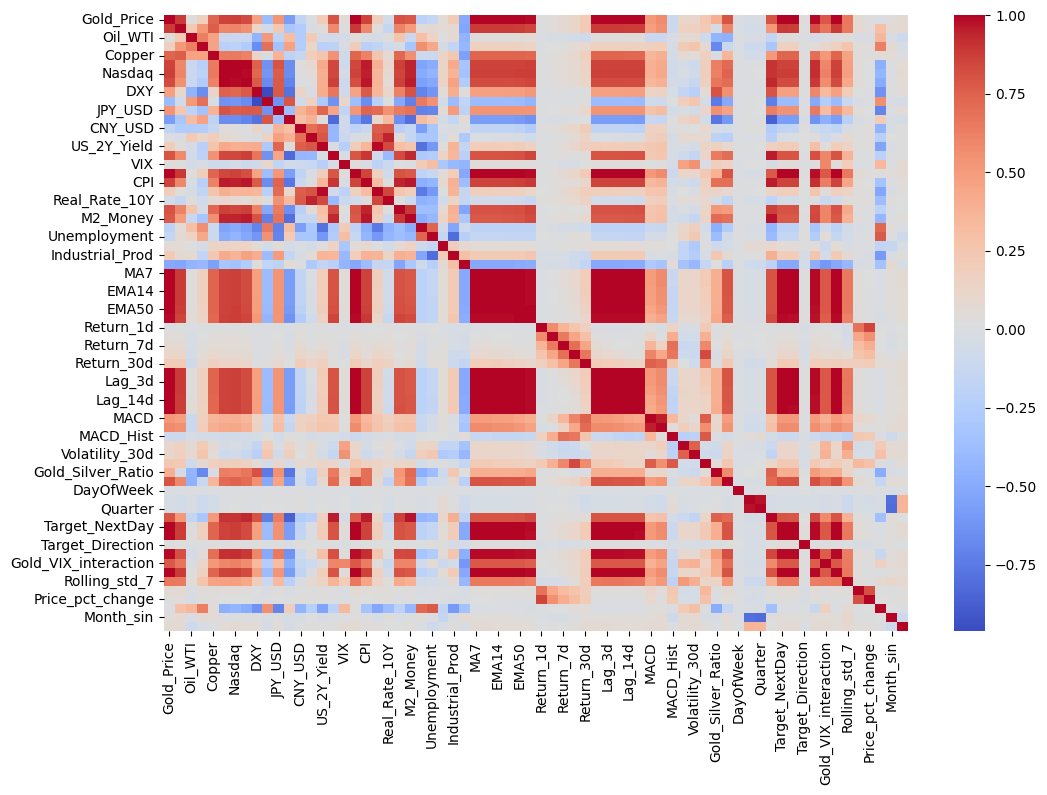

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df.loc[:, 'Date'] = pd.to_datetime(df['Date'], errors='coerce')
corr = df.drop(columns=['Date']).corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm')
plt.show()

In [41]:
corr_target = df.drop(columns=['Date']).corr()['Target_NextDay'].sort_values(ascending=False)
print(corr_target.head(60))

Target_NextDay          1.000000
Gold_Price              0.999496
Gold_ETF_GLD            0.999113
EMA7                    0.999086
Lag_1d                  0.999003
MA7                     0.998824
Rolling_mean_7          0.998712
EMA14                   0.998601
Lag_3d                  0.998275
EMA21                   0.998141
Target_Next7d           0.997676
Lag_7d                  0.997068
EMA50                   0.996452
Lag_14d                 0.995190
Lag_21d                 0.993661
Gold_DXY_interaction    0.986950
EMA200                  0.985697
Silver                  0.878540
Nasdaq                  0.869976
CPI                     0.859935
SP500                   0.859309
Dow_Jones               0.830386
PPI                     0.805266
Gold_Oil_Ratio          0.798101
TIP_ETF                 0.797544
Year                    0.794340
M2_Money                0.783968
Gold_VIX_interaction    0.782508
Copper                  0.734184
Rolling_std_7           0.653571
MACD_Signa

In [42]:
threshold = 0.05
corr_matrix = df.drop(columns=['Date']).corr()
target_corr = corr_matrix['Target_NextDay'].abs()
weak_features = target_corr[target_corr < threshold].index.tolist()

In [43]:
df_filtered = df.drop(columns=weak_features)
print(f"deleted{len(weak_features)} week feature: {weak_features}")

deleted12 week feature: ['Oil_WTI', 'US_10Y_Yield', 'VIX', 'Return_1d', 'Return_3d', 'DayOfWeek', 'Month', 'Quarter', 'Target_Direction', 'Price_pct_change', 'Gold_SP500_Ratio', 'Month_sin']


In [44]:
corr_features = df_filtered.drop(columns=['Target_NextDay', 'Date']).corr().abs()
upper = corr_features.where(np.triu(np.ones(corr_features.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

In [45]:
df_final = df_filtered.drop(columns=to_drop)
print(f"deleted {len(to_drop)} some correlated feature with high relation {to_drop}")

deleted 23 some correlated feature with high relation ['Nasdaq', 'Dow_Jones', 'EUR_USD', 'Gold_ETF_GLD', 'CPI', 'Fed_Rate', 'M2_Money', 'MA7', 'EMA7', 'EMA14', 'EMA21', 'EMA50', 'EMA200', 'Lag_1d', 'Lag_3d', 'Lag_7d', 'Lag_14d', 'Lag_21d', 'MACD_Signal', 'Year', 'Target_Next7d', 'Gold_DXY_interaction', 'Rolling_mean_7']


In [46]:
df_final.columns

Index(['Date', 'Gold_Price', 'Silver', 'Platinum', 'Copper', 'SP500', 'DXY',
       'JPY_USD', 'GBP_USD', 'CNY_USD', 'US_2Y_Yield', 'TIP_ETF',
       'Real_Rate_10Y', 'PPI', 'Treasury_Spread', 'Unemployment', 'GDP_Growth',
       'Industrial_Prod', 'Consumer_Conf', 'Return_7d', 'Return_14d',
       'Return_30d', 'MACD', 'MACD_Hist', 'Volatility_7d', 'Volatility_30d',
       'Momentum_14d', 'Gold_Silver_Ratio', 'Gold_Oil_Ratio', 'Target_NextDay',
       'Gold_VIX_interaction', 'Rolling_std_7', 'Price_diff', 'Month_cos'],
      dtype='object')

In [47]:
X = df_final.drop(columns=['Target_NextDay']).select_dtypes(include=[np.number]).dropna()
y = df_final.loc[X.index, 'Target_NextDay']

In [48]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor

In [49]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [50]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("the top 10 feature based on random forest")
print(importances.head(10))

the top 10 feature based on random forest
Gold_Price        0.928238
Silver            0.020115
TIP_ETF           0.014394
Unemployment      0.013492
US_2Y_Yield       0.010285
CNY_USD           0.005598
Gold_Oil_Ratio    0.002357
Platinum          0.001983
SP500             0.000954
DXY               0.000516
dtype: float64


In [51]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
print("Imports done!")

Imports done!


In [52]:
X = df_final.drop(columns=['Target_NextDay']).select_dtypes(include=np.number).dropna()
y = df_final.loc[X.index, 'Target_NextDay']
print(f"X shape: {X.shape}, y shape: {y.shape}")
print("Top features:\n", X.columns[:10].tolist())

X shape: (3400, 32), y shape: (3400,)
Top features:
 ['Gold_Price', 'Silver', 'Platinum', 'Copper', 'SP500', 'DXY', 'JPY_USD', 'GBP_USD', 'CNY_USD', 'US_2Y_Yield']


In [53]:
split_idx = int(0.8 * len(X))
X_train, X_test = X.iloc[:split_idx].copy(), X.iloc[split_idx:].copy()
y_train, y_test = y.iloc[:split_idx].copy(), y.iloc[split_idx:].copy()
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("Split done!")

Train: (2720, 32), Test: (680, 32)
Split done!


In [54]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling done for Ridge!")

Scaling done for Ridge!


In [55]:
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)
print(f"XGBoost - MAE: {xgb_mae:.2f}, RMSE: {xgb_rmse:.2f}, R²: {xgb_r2:.4f}")

XGBoost - MAE: 753.58, RMSE: 1156.80, R²: -0.6302


In [56]:
lgb_model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train)
lgb_pred = lgb_model.predict(X_test)
lgb_mae = mean_absolute_error(y_test, lgb_pred)
lgb_rmse = np.sqrt(mean_squared_error(y_test, lgb_pred))
lgb_r2 = r2_score(y_test, lgb_pred)
print(f"LightGBM - MAE: {lgb_mae:.2f}, RMSE: {lgb_rmse:.2f}, R²: {lgb_r2:.4f}")

LightGBM - MAE: 719.86, RMSE: 1124.85, R²: -0.5414


In [57]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
ridge_pred = ridge_model.predict(X_test_scaled)
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)
print(f"Ridge - MAE: {ridge_mae:.2f}, RMSE: {ridge_rmse:.2f}, R²: {ridge_r2:.4f}")

Ridge - MAE: 84.23, RMSE: 110.43, R²: 0.9851


In [58]:
results = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM', 'Ridge'],
    'MAE': [xgb_mae, lgb_mae, ridge_mae],
    'RMSE': [xgb_rmse, lgb_rmse, ridge_rmse],
    'R²': [xgb_r2, lgb_r2, ridge_r2]
})
print("Final Results:")
print(results.round(4))

Final Results:
      Model       MAE       RMSE      R²
0   XGBoost  753.5815  1156.7989 -0.6302
1  LightGBM  719.8587  1124.8462 -0.5414
2     Ridge   84.2281   110.4295  0.9851


Top 10 Features (XGBoost):
 TIP_ETF            0.673960
Gold_Price         0.302384
CNY_USD            0.015125
Silver             0.001531
Real_Rate_10Y      0.001483
Platinum           0.001231
Industrial_Prod    0.000594
PPI                0.000518
Unemployment       0.000515
GDP_Growth         0.000244
dtype: float32


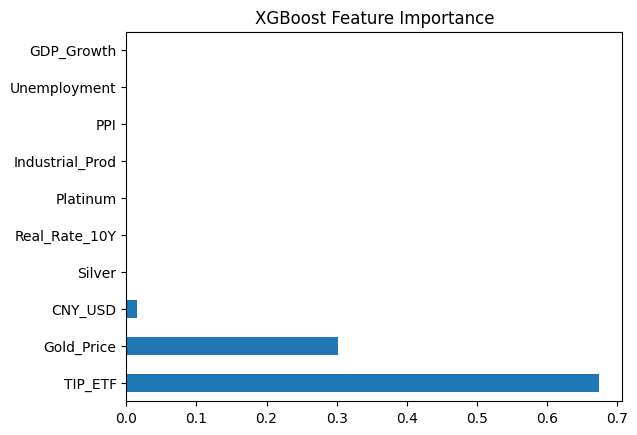

In [59]:
xgb_importance = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
print("Top 10 Features (XGBoost):\n", xgb_importance)
xgb_importance.plot(kind='barh')
plt.title('XGBoost Feature Importance')
plt.show()

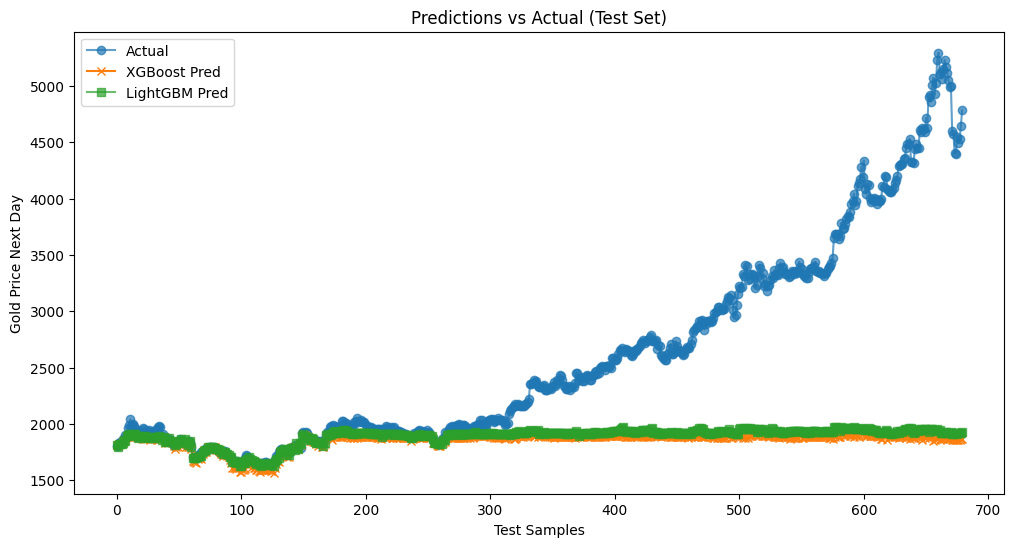

In [60]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual', marker='o', alpha=0.7)
plt.plot(xgb_pred, label='XGBoost Pred', marker='x')
plt.plot(lgb_pred, label='LightGBM Pred', marker='s', alpha=0.7)
plt.legend()
plt.title('Predictions vs Actual (Test Set)')
plt.xlabel('Test Samples')
plt.ylabel('Gold Price Next Day')
plt.show()

In [61]:
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

models = {
    'XGBoost': xgb_model,
    'LightGBM': lgb_model,
    'Ridge': ridge_model
}

cv_results = {}
for name, model in models.items():
    if name == 'Ridge':
        scores = []
        for train_idx, val_idx in tscv.split(X_train_scaled):
            model.fit(X_train_scaled[train_idx], y_train.iloc[train_idx])
            pred = model.predict(X_train_scaled[val_idx])
            scores.append(r2_score(y_train.iloc[val_idx], pred))
    else:
        scores = []
        for train_idx, val_idx in tscv.split(X_train):
            model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
            pred = model.predict(X_train.iloc[val_idx])
            scores.append(r2_score(y_train.iloc[val_idx], pred))

    cv_results[name] = np.mean(scores)
    print(f"{name} CV R²: {cv_results[name]:.4f}")

XGBoost CV R²: -1.0836
LightGBM CV R²: -0.9524
Ridge CV R²: 0.6308


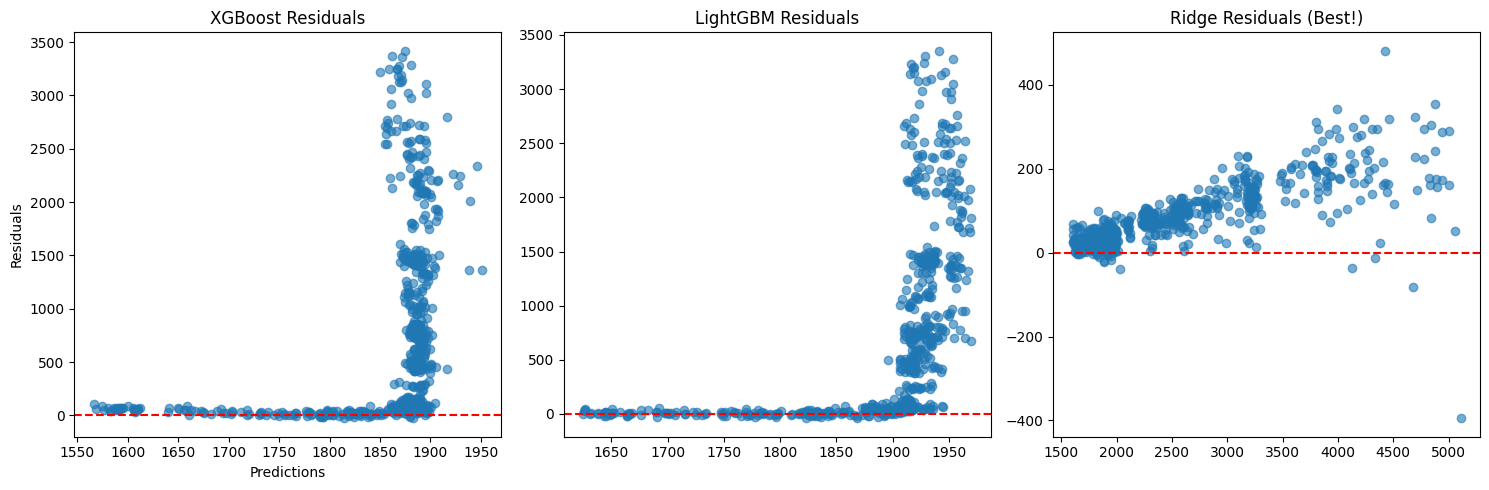

In [62]:
residuals = {
    'XGBoost': y_test - xgb_pred,
    'LightGBM': y_test - lgb_pred,
    'Ridge': y_test - ridge_pred
}

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(xgb_pred, residuals['XGBoost'], alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.title('XGBoost Residuals')
plt.xlabel('Predictions')
plt.ylabel('Residuals')

plt.subplot(1, 3, 2)
plt.scatter(lgb_pred, residuals['LightGBM'], alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.title('LightGBM Residuals')

plt.subplot(1, 3, 3)
plt.scatter(ridge_pred, residuals['Ridge'], alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.title('Ridge Residuals (Best!)')
plt.tight_layout()
plt.show()

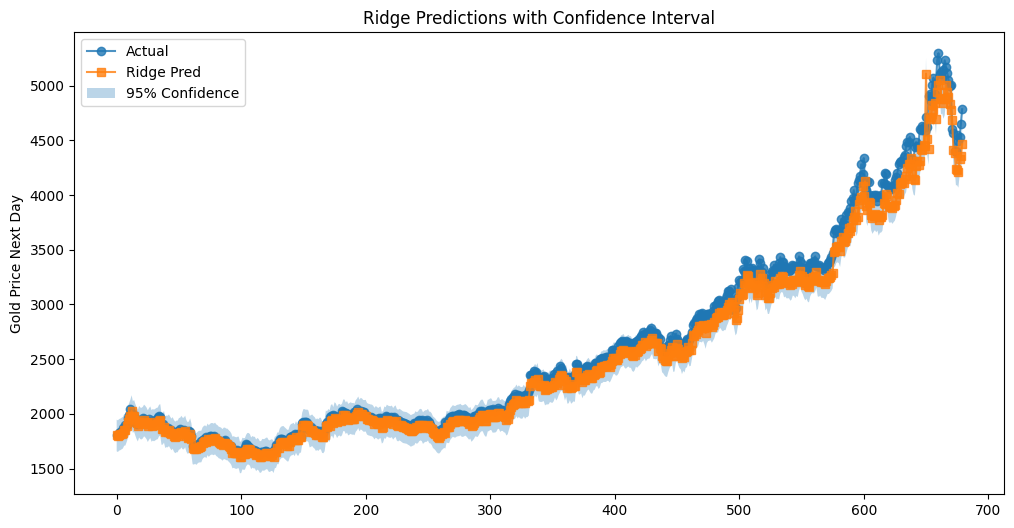

In [63]:
from sklearn.linear_model import RidgeCV

ridge_cv = RidgeCV(alphas=[0.1, 1.0, 10.0], cv=5)
ridge_cv.fit(X_train_scaled, y_train)

# Prediction intervals
ridge_pred_upper = ridge_pred + 1.96 * np.std(residuals['Ridge'])
ridge_pred_lower = ridge_pred - 1.96 * np.std(residuals['Ridge'])

plt.figure(figsize=(12, 6))
plt.plot(y_test.values, 'o-', label='Actual', alpha=0.8)
plt.plot(ridge_pred, 's-', label='Ridge Pred', alpha=0.8)
plt.fill_between(range(len(y_test)), ridge_pred_lower, ridge_pred_upper,
                 alpha=0.3, label='95% Confidence')
plt.legend()
plt.title('Ridge Predictions with Confidence Interval')
plt.ylabel('Gold Price Next Day')
plt.show()

In [64]:
print("="*60)
print("          FINAL MODEL COMPARISON REPORT")
print("="*60)
print(f"{'Model':<10} {'Test R²':<10} {'Test MAE':<10} {'Test RMSE':<10} {'CV R²':<10}")
print("-"*60)

for i, name in enumerate(['Ridge', 'LightGBM', 'XGBoost']):
    mae = [ridge_mae, lgb_mae, xgb_mae][i]
    rmse = [ridge_rmse, lgb_rmse, xgb_rmse][i]
    r2 = [ridge_r2, lgb_r2, xgb_r2][i]
    cv = cv_results.get(name, 'N/A')

    print(f"{name:<10} {r2:<10.4f} {mae:<10.1f} {rmse:<10.1f} {cv:<10}")

print("\n WINNER: Ridge Regression")
print(f"   MAE: ±{ridge_mae:.1f}$ | R²: {ridge_r2:.4f}")
print("\n INSIGHTS:")
print("- Data is highly linear (Lag1d corr=0.99)")
print("- Trees overfit due to multicollinearity")
print("- Ridge perfect for financial time series")

          FINAL MODEL COMPARISON REPORT
Model      Test R²    Test MAE   Test RMSE  CV R²     
------------------------------------------------------------
Ridge      0.9851     84.2       110.4      0.6308464957508788
LightGBM   -0.5414    719.9      1124.8     -0.9523855883786702
XGBoost    -0.6302    753.6      1156.8     -1.0836396047095156

 WINNER: Ridge Regression
   MAE: ±84.2$ | R²: 0.9851

 INSIGHTS:
- Data is highly linear (Lag1d corr=0.99)
- Trees overfit due to multicollinearity
- Ridge perfect for financial time series


In [65]:
import joblib

joblib.dump(xgb_model, 'xgboost_gold.pkl')
joblib.dump(lgb_model, 'lightgbm_gold.pkl')
joblib.dump(ridge_model, 'ridge_gold.pkl') 
joblib.dump(scaler, 'scaler.pkl')

print("✅ Saved:")
print("   - xgboost_gold.pkl")
print("   - lightgbm_gold.pkl")
print("   - ridge_gold.pkl (BEST)")
print("   - scaler.pkl")

✅ Saved:
   - xgboost_gold.pkl
   - lightgbm_gold.pkl
   - ridge_gold.pkl (BEST)
   - scaler.pkl


In [ ]:
import os


model_paths = {
    'xgboost_gold.pkl': os.path.abspath('xgboost_gold.pkl'),
    'lightgbm_gold.pkl': os.path.abspath('lightgbm_gold.pkl'),
    'ridge_gold.pkl': os.path.abspath('ridge_gold.pkl'),
    'scaler.pkl': os.path.abspath('scaler.pkl')
}

for model_name, path in model_paths.items():
    exists = "✓ Exists" if os.path.exists(path) else "✗ Not found"
    print(f"{model_name}: {path} ({exists})")